## Data loading + class balance check

In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2]:
numeric_charges = pd.to_numeric(df['TotalCharges'], errors='coerce')
blank_mask = numeric_charges.isnull()

n_blanks = blank_mask.sum()
tenure_where_blank = df.loc[blank_mask, 'tenure']
all_zero = tenure_where_blank.eq(0).all()

raw_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True)

print(f"Number of blank TotalCharges: {n_blanks}")
print(f"All blank TotalCharges have tenure of 0: {all_zero}")
print(f"Raw counts of Churn: {raw_counts.to_dict()}")
print(f"Churn rate: {churn_rate.to_dict()}")

Number of blank TotalCharges: 11
All blank TotalCharges have tenure of 0: True
Raw counts of Churn: {'No': 5174, 'Yes': 1869}
Churn rate: {'No': 0.7346301292063041, 'Yes': 0.2653698707936959}


**Findings:** 11 blank `TotalCharges` values, all at `tenure == 0` - not missing data, just unbilled new customers. `Churn` is 73.5% No / 26.5% Yes. Seemingly imbalanced.

## Feature Engineering

In [3]:
def add_tenure_buckets(df: pd.DataFrame) -> pd.DataFrame:
    bins = [0, 12, 24, 36, 48, 60, np.inf]
    labels = ['0-11', '12-23', '24-35', '36-47', '48-59', '60+']
    df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)
    return df

def add_charges_ratio(df: pd.DataFrame) -> pd.DataFrame:
    total_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['charges_ratio'] = pd.to_numeric(df['MonthlyCharges'] / total_numeric.replace(0, np.nan), errors='coerce')
    return df

def add_service_count(df: pd.DataFrame) -> pd.DataFrame:
    service_columns = [
        'PhoneService', 'MultipleLines', 'OnlineSecurity',
        'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
        'StreamingMovies'
    ]
    df['service_count'] = df[service_columns].apply(lambda x: (x == 'Yes').sum(), axis=1)
    return df

In [4]:
# Calling Functions to test
df = add_tenure_buckets(df)
df = add_charges_ratio(df)
df = add_service_count(df)

print(df[['tenure', 'tenure_bucket']].head(10))
print(df.loc[blank_mask, ['TotalCharges', 'charges_ratio']])
print(df[['MonthlyCharges', 'TotalCharges', 'charges_ratio']].head(10))
print(df['service_count'].value_counts())

   tenure tenure_bucket
0       1          0-11
1      34         24-35
2       2          0-11
3      45         36-47
4       2          0-11
5       8          0-11
6      22         12-23
7      10          0-11
8      28         24-35
9      62           60+
     TotalCharges  charges_ratio
488                          NaN
753                          NaN
936                          NaN
1082                         NaN
1340                         NaN
3331                         NaN
3826                         NaN
4380                         NaN
5218                         NaN
6670                         NaN
6754                         NaN
   MonthlyCharges TotalCharges  charges_ratio
0           29.85        29.85       1.000000
1           56.95       1889.5       0.030140
2           53.85       108.15       0.497920
3           42.30      1840.75       0.022980
4           70.70       151.65       0.466205
5           99.65        820.5       0.121450
6           89.10 

**Findings:** Three features added. `tenure_bucket` splits tenure into 12-month domain-defined ranges (`pd.cut`, not quantiles - the ranges are meant to read as "new / established / loyal" customer stages, not just equal-sized groups). `charges_ratio` (`MonthlyCharges` / `TotalCharges`) needed a guard against the 11 blank-`TotalCharges` rows flagged in Step 1 — confirmed all 11 resolve to `NaN` rather than `inf` or a crash. `service_count` sums 8 add-on service columns per customer (0–8 range); `InternetService` was deliberately excluded since its values (`DSL`/`Fiber optic`/`No`) aren't a Yes/No pair like the rest, so it can't reuse the same count logic without separate handling.

## EDA — Churn by Category

Churn rate broken down by contract type, payment method, and tenure bucket.

In [11]:
def churn_rate_by(df: pd.DataFrame, column: str) -> pd.Series:
    return (
        df.groupby(column, observed=True)['Churn']
        .apply(lambda x: (x == 'Yes').mean())
        .sort_values(ascending=False)
    )

print(churn_rate_by(df, 'Contract'))
print()
print(churn_rate_by(df, 'PaymentMethod'))
print()
print(churn_rate_by(df, 'tenure_bucket'))

pd.crosstab(df['Contract'], df['tenure_bucket'], normalize='index').round(3)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64

tenure_bucket
0-11     0.482842
12-23    0.295129
24-35    0.220320
36-47    0.195187
48-59    0.150000
60+      0.066757
Name: Churn, dtype: float64


tenure_bucket,0-11,12-23,24-35,36-47,48-59,60+
Contract,,,,,,
Month-to-month,0.492,0.197,0.135,0.083,0.059,0.033
One year,0.069,0.135,0.170,0.176,0.221,0.229
Two year,0.035,0.049,0.061,0.098,0.156,0.601


## Churn Rate Chart — Contract, Payment Method, Tenure Bucket

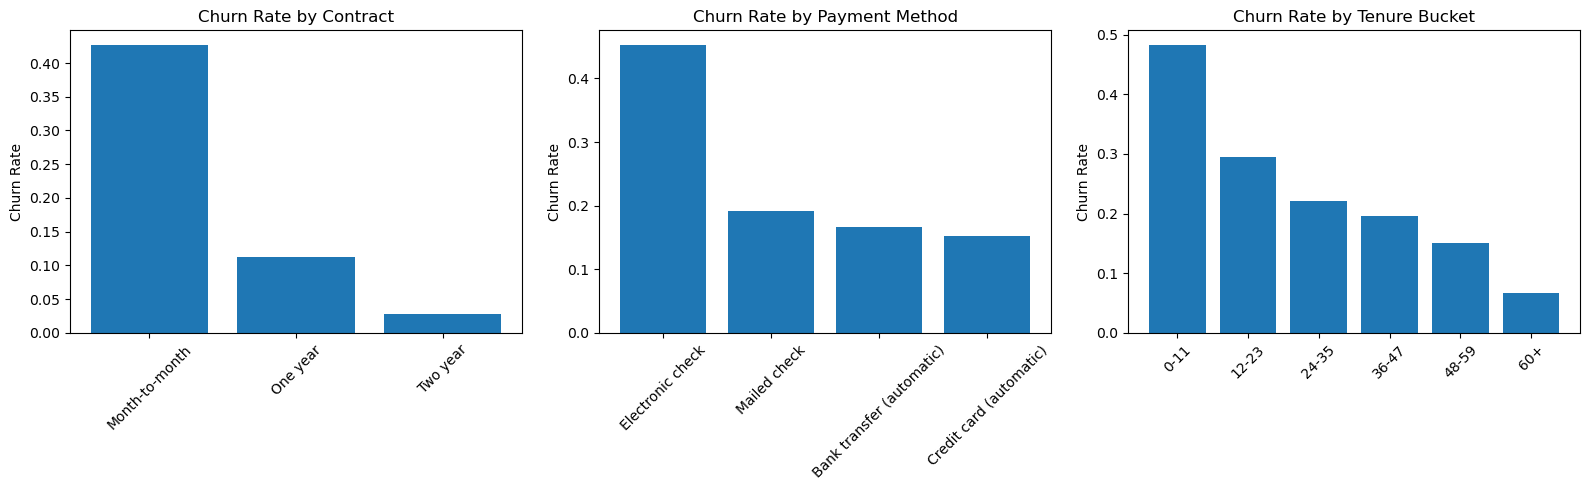

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

columns = ['Contract', 'PaymentMethod', 'tenure_bucket']
titles = ['Churn Rate by Contract', 'Churn Rate by Payment Method', 'Churn Rate by Tenure Bucket']

for ax, column, title in zip(axs, columns, titles):
    rates = churn_rate_by(df, column)
    ax.bar(rates.index, rates.values)
    ax.set_title(title)
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Findings:** All three breakdowns show a strong, monotonic relationship with churn. `Contract` has the widest spread (Month-to-month 42.7% → One year 11.3% → Two year 2.8%, ~15x range), likely a mix of switching cost (month-to-month customers can leave penalty-free) and selection effect (customers who choose flexibility may already be less committed).

`PaymentMethod` splits roughly along automatic vs manual billing (Bank transfer/Credit card ~15-17% vs Mailed check 19.1%), but Electronic check (45.3%) churns well above the other manual method, so payment friction alone doesn't fully explain it, flagging as correlation worth a closer look rather than a settled mechanism. `tenure_bucket` shows a clean lifecycle trend (48.3% new customers down to 6.7% at 60+ months). 

A `Contract` × `tenure_bucket` crosstab (normalized by row) shows these two features partially overlap: Month-to-month customers are heavily skewed new (49.2% in the 0-11 bucket) and Two year customers are heavily skewed long-tenure (60.1% in 60+), so those two contract types are capturing a lot of the same signal as tenure_bucket. 
One year contracts are the exception, fairly evenly spread across tenure buckets rather than clustering at one end. Not fully redundant, but the overlap is worth keeping in mind for modelling (multicollinearity matters more for logistic regression than random forest).